In [1]:
# Install libraries yang dibutuhkan
!pip install -q transformers[torch] datasets accelerate

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


```markdown
# SMART CAMPUS HELPDESK - CATEGORY MODEL TRAINING SCRIPT
**Universitas Halu Oleo (UHO) - Tugas Akhir Machine Learning**

**Fungsi:** Melakukan fine-tuning model IndoBERT untuk mengklasifikasikan 6 Kategori Departemen Keluhan.
```

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Reproduksibilitas
def setup_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    set_seed(seed)

setup_seed(42)

# Set path
DATA_DIR = "./data"
MODEL_OUTPUT_DIR = "./models/category_model_checkpoints"
FINAL_MODEL_DIR = "./models/kategori_final"

print("================================================================================")
print("[INFO] SETUP SELESAI & REPRODUKSIBILITAS DIKUNCI")
print("================================================================================")

[INFO] SETUP SELESAI & REPRODUKSIBILITAS DIKUNCI


In [3]:
# Update path sesuai permintaan untuk Google Drive
DATA_DIR = "/content/drive/MyDrive/TugasMachineLearning/project akhir/data"
MODEL_OUTPUT_DIR = "/content/drive/MyDrive/TugasMachineLearning/project akhir/models/category_model_checkpoints"
FINAL_MODEL_DIR = "/content/drive/MyDrive/TugasMachineLearning/project akhir/models/kategori_final"

# Pastikan folder output tersedia
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

print(f"[INFO] Path data diatur ke: {DATA_DIR}")

[INFO] Path data diatur ke: /content/drive/MyDrive/TugasMachineLearning/project akhir/data


In [4]:
# 2. Muat Dataset Hasil Stratified Split
train_path = os.path.join(DATA_DIR, "train.csv")
val_path = os.path.join(DATA_DIR, "val.csv")
test_path = os.path.join(DATA_DIR, "test.csv")

# Pastikan folder data ada
if not os.path.exists(DATA_DIR): os.makedirs(DATA_DIR)

for path in [train_path, val_path, test_path]:
    if not os.path.exists(path):
        print(f"[!] Peringatan: Berkas '{path}' tidak ditemukan. Pastikan data sudah diunggah.")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

# 3. Pemetaan Label Kategori
LABEL2ID = {
    'FASILITAS': 0,
    'JARINGAN_IT': 1,
    'AKADEMIK': 2,
    'KEUANGAN': 3,
    'KEMAHASISWAAN': 4,
    'LAINNYA': 5
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

train_df['label'] = train_df['category'].map(LABEL2ID)
val_df['label']   = val_df['category'].map(LABEL2ID)
test_df['label']  = test_df['category'].map(LABEL2ID)

print(f"[OK] Data Latih: {len(train_df)}, Validasi: {len(val_df)}, Test: {len(test_df)}")

[OK] Data Latih: 1448, Validasi: 181, Test: 181


In [5]:
# 4. Tokenisasi
MODEL_NAME = "indobenchmark/indobert-base-p1"
print(f"[INFO] Mengunduh Tokenizer: '{MODEL_NAME}'...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

train_ds = Dataset.from_pandas(train_df[['text', 'label']])
val_ds   = Dataset.from_pandas(val_df[['text', 'label']])
test_ds  = Dataset.from_pandas(test_df[['text', 'label']])

train_tokenized = train_ds.map(tokenize_function, batched=True)
val_tokenized   = val_ds.map(tokenize_function, batched=True)
test_tokenized  = test_ds.map(tokenize_function, batched=True)

[INFO] Mengunduh Tokenizer: 'indobenchmark/indobert-base-p1'...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/1448 [00:00<?, ? examples/s]

Map:   0%|          | 0/181 [00:00<?, ? examples/s]

Map:   0%|          | 0/181 [00:00<?, ? examples/s]

In [6]:
# 5. Load Model & Metrics
print(f"[INFO] Mengunduh Model Pra-Latih: '{MODEL_NAME}'")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL2ID),
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1_macro': f1,
        'precision_macro': precision,
        'recall_macro': recall
    }

[INFO] Mengunduh Model Pra-Latih: 'indobenchmark/indobert-base-p1'


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
# 6. Training Configuration & Execution
training_args = TrainingArguments(
    output_dir=MODEL_OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',      # Diperbarui dari evaluation_strategy ke eval_strategy
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
)

print("[INFO] Memulai Proses Training...")
trainer.train()

# Simpan Model
if not os.path.exists(FINAL_MODEL_DIR): os.makedirs(FINAL_MODEL_DIR)
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[INFO] Memulai Proses Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,1.424752,0.115881,0.977901,0.977450,0.977246,0.978748
2,0.067582,0.037770,0.994475,0.994350,0.994444,0.994444
3,0.011780,0.027829,0.988950,0.989846,0.991305,0.988697
4,0.003562,0.018474,0.994475,0.994145,0.994048,0.994444
5,0.005703,0.014289,0.994475,0.994145,0.994048,0.994444


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/TugasMachineLearning/project akhir/models/kategori_final/tokenizer_config.json',
 '/content/drive/MyDrive/TugasMachineLearning/project akhir/models/kategori_final/tokenizer.json')


[INFO] EVALUASI PADA TEST SET



--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

    FASILITAS     1.0000    1.0000    1.0000        41
  JARINGAN_IT     0.9714    1.0000    0.9855        34
     AKADEMIK     1.0000    0.9655    0.9825        29
     KEUANGAN     1.0000    1.0000    1.0000        20
KEMAHASISWAAN     1.0000    1.0000    1.0000        28
      LAINNYA     1.0000    1.0000    1.0000        29

     accuracy                         0.9945       181
    macro avg     0.9952    0.9943    0.9947       181
 weighted avg     0.9946    0.9945    0.9945       181



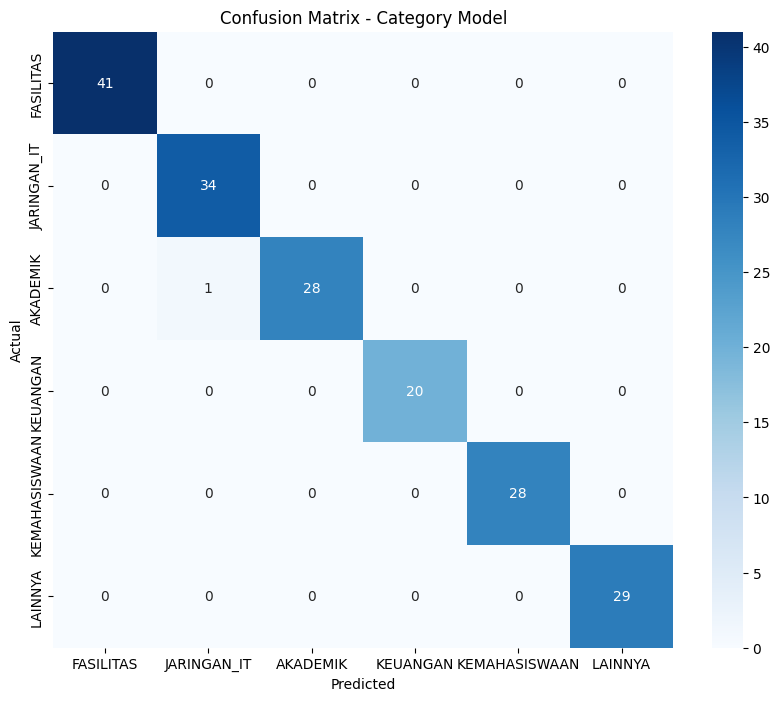

In [8]:
# 7. Evaluasi Akhir
print("\n[INFO] EVALUASI PADA TEST SET")
test_results = trainer.predict(test_tokenized)

y_pred = np.argmax(test_results.predictions, axis=-1)
y_true = test_df['label'].values

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=list(LABEL2ID.keys()), digits=4))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(LABEL2ID.keys()), yticklabels=list(LABEL2ID.keys()))
plt.title('Confusion Matrix - Category Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

```markdown
# 8. Uji Coba Prediksi (Inference)
Setelah model dilatih dan disimpan, gunakan sel di bawah ini untuk mencoba memasukkan teks keluhan baru.
```

In [9]:
from transformers import pipeline

# Memuat model yang telah dilatih dari Google Drive
print(f"[INFO] Memuat model dari: {FINAL_MODEL_DIR}")

# Membuat pipeline klasifikasi
nlp_classifier = pipeline(
    "sentiment-analysis",
    model=FINAL_MODEL_DIR,
    tokenizer=FINAL_MODEL_DIR,
    device=0 if torch.cuda.is_available() else -1
)

def prediksi_keluhan(teks):
    hasil = nlp_classifier(teks)
    label = hasil[0]['label']
    skor = hasil[0]['score']
    print(f"\nTeks Keluhan: {teks}")
    print(f"Prediksi Kategori: {label} (Skor Keyakinan: {skor:.4f})")

# --- SILAHKAN COBA DI SINI ---
contoh_teks = "di ruangan belajarnya lanatai 3 itu banyak puntung rokok yang berserakan"
prediksi_keluhan(contoh_teks)

contoh_teks_2 = "Bagaimana cara mengajukan keringanan UKT semester depan?"
prediksi_keluhan(contoh_teks_2)

[INFO] Memuat model dari: /content/drive/MyDrive/TugasMachineLearning/project akhir/models/kategori_final


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Teks Keluhan: AC di ruangan kelas 302 bocor dan sangat panas, tolong diperbaiki.
Prediksi Kategori: FASILITAS (Skor Keyakinan: 0.9953)

Teks Keluhan: Bagaimana cara mengajukan keringanan UKT semester depan?
Prediksi Kategori: KEUANGAN (Skor Keyakinan: 0.9348)


In [19]:
teks_keuangan_kritis = "min tolong banget ini portal pembayaran ukt error terus dari semalam, padahal hari ini batas terakhir bayar buat syarat isi krs!! kalo ga bayar saya cuti ini"
prediksi_keluhan(teks_keuangan_kritis)

teks_jaringan_fasilitas = "kabel lan di lab komputer lantai 2 banyak yang putus digigit tikus, kita sekelas gabisa konek ke server lokal buat praktek"
prediksi_keluhan(teks_jaringan_fasilitas)

teks_ganda = "dosennya telat masuk 2 jam bikin rugi waktu aja, mana ac di ruangan b302 panas banget kayak oven, gerah parah"
prediksi_keluhan(teks_ganda)

teks_kemahasiswaan = "info dong kak, untuk sk kepengurusan bem fakultas tahun ini kok belum diupload di web ya? mau dipake buat syarat pengajuan beasiswa"
prediksi_keluhan(teks_kemahasiswaan)



Teks Keluhan: min tolong banget ini portal pembayaran ukt error terus dari semalam, padahal hari ini batas terakhir bayar buat syarat isi krs!! kalo ga bayar saya cuti ini
Prediksi Kategori: KEUANGAN (Skor Keyakinan: 0.9335)

Teks Keluhan: kabel lan di lab komputer lantai 2 banyak yang putus digigit tikus, kita sekelas gabisa konek ke server lokal buat praktek
Prediksi Kategori: JARINGAN_IT (Skor Keyakinan: 0.9481)

Teks Keluhan: dosennya telat masuk 2 jam bikin rugi waktu aja, mana ac di ruangan b302 panas banget kayak oven, gerah parah
Prediksi Kategori: FASILITAS (Skor Keyakinan: 0.8903)

Teks Keluhan: info dong kak, untuk sk kepengurusan bem fakultas tahun ini kok belum diupload di web ya? mau dipake buat syarat pengajuan beasiswa
Prediksi Kategori: AKADEMIK (Skor Keyakinan: 0.4971)


In [20]:
teks_sarkas = "mantap bgt fasilitas kampus kita, tiap hujan deras mhs gausah jauh-jauh ke kolam renang, di parkiran rektorat udah jadi waterboom gratis."
prediksi_keluhan(teks_sarkas)

teks_typo = "m1n tlg dnk web krsnya ngelag parah anjrit gbs pencet matkul sisa 1 slot doang nih keburu diembat org"

prediksi_keluhan(teks_typo)



teks_pengecoh = "pas saya lagi antri di loket pembayaran ukt, tiba2 plafon di atas loketnya ambruk kena kepala temen saya, tolong woi panggil ambulans!"

prediksi_keluhan(teks_pengecoh)



teks_info = "maaf min mau nanya, kalau mau legalisir ijazah untuk alumni angkatan 2020 syaratnya harus bawa dokumen asli atau cukup fotokopian aja ya?"

prediksi_keluhan(teks_info)






Teks Keluhan: mantap bgt fasilitas kampus kita, tiap hujan deras mhs gausah jauh-jauh ke kolam renang, di parkiran rektorat udah jadi waterboom gratis.
Prediksi Kategori: FASILITAS (Skor Keyakinan: 0.9831)

Teks Keluhan: m1n tlg dnk web krsnya ngelag parah anjrit gbs pencet matkul sisa 1 slot doang nih keburu diembat org
Prediksi Kategori: AKADEMIK (Skor Keyakinan: 0.9858)

Teks Keluhan: pas saya lagi antri di loket pembayaran ukt, tiba2 plafon di atas loketnya ambruk kena kepala temen saya, tolong woi panggil ambulans!
Prediksi Kategori: FASILITAS (Skor Keyakinan: 0.9889)

Teks Keluhan: maaf min mau nanya, kalau mau legalisir ijazah untuk alumni angkatan 2020 syaratnya harus bawa dokumen asli atau cukup fotokopian aja ya?
Prediksi Kategori: AKADEMIK (Skor Keyakinan: 0.7716)
